In [1]:
# =========================================================
# CELL 1 - IMPORT LIBRARY + KONEKSI SUPABASE
# =========================================================
import os
import re
import json
import sys
import scipy.sparse as sp
import pandas as pd
import numpy as np

from collections import Counter
from datetime import datetime, timezone
from pathlib import Path
from dotenv import load_dotenv
from supabase import create_client
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.metrics.pairwise import cosine_similarity

BACKEND_DIR = next(
    path for path in (Path.cwd(), Path.cwd().parent, Path.cwd() / "backend")
    if (path / "src" / "preprocessing").is_dir()
)
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

from src.preprocessing.stopwords import get_stopwords

load_dotenv()

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_SERVICE_ROLE_KEY") or os.getenv("SUPABASE_KEY")

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

SOURCE_TABLE = "cleaned_papers_results"
SIMILARITY_TABLE = "similarity_results"

print("✅ Supabase client siap")

✅ Supabase client siap


In [2]:
# =========================================================
# CELL 2 - LOAD FILE VSM HASIL TF-IDF
# =========================================================
base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
tfidf_dir = os.path.join(base_dir, "data", "tfidf")
results_dir = os.path.join(base_dir, "data", "cosine_results")

os.makedirs(results_dir, exist_ok=True)

tfidf_matrix = sp.load_npz(os.path.join(tfidf_dir, "tfidf_matrix.npz"))

with open(os.path.join(tfidf_dir, "tfidf_terms.json"), "r", encoding="utf-8") as file:
    terms = json.load(file)

with open(os.path.join(tfidf_dir, "tfidf_doc_ids.json"), "r", encoding="utf-8") as file:
    doc_ids = json.load(file)

with open(os.path.join(tfidf_dir, "idf_scores.json"), "r", encoding="utf-8") as file:
    idf_scores = json.load(file)

tfidf_documents = pd.read_csv(os.path.join(tfidf_dir, "tfidf_documents.csv"))

doc_ids = [int(doc_id) for doc_id in doc_ids]

print("✅ File VSM berhasil dimuat")
print("Matrix TF-IDF:", tfidf_matrix.shape)
print("Jumlah terms:", len(terms))
print("Jumlah doc_ids:", len(doc_ids))

✅ File VSM berhasil dimuat
Matrix TF-IDF: (200, 1723)
Jumlah terms: 1723
Jumlah doc_ids: 200


In [3]:
# =========================================================
# CELL 3 - LOAD METADATA ARTIKEL DARI SUPABASE
# =========================================================
all_data = []
batch_size = 1000
offset = 0

selected_columns = """
id,
title,
abstract,
authors,
year,
source,
category,
pdf_url,
url,
scrape_status
"""

while True:
    response = (
        supabase.table(SOURCE_TABLE)
        .select(selected_columns)
        .range(offset, offset + batch_size - 1)
        .execute()
    )

    batch = response.data or []

    if not batch:
        break

    all_data.extend(batch)

    if len(batch) < batch_size:
        break

    offset += batch_size

metadata_df = pd.DataFrame(all_data)

if metadata_df.empty:
    raise ValueError("❌ Data cleaned_papers_results kosong.")

metadata_df["id"] = metadata_df["id"].astype("int64")

doc_index = pd.DataFrame({"id": doc_ids})
doc_index = doc_index.merge(metadata_df, on="id", how="left")
doc_index = doc_index.merge(
    tfidf_documents[["id", "document_text"]],
    on="id",
    how="left",
)

for col in ["title", "abstract", "authors", "source", "category", "pdf_url", "url", "scrape_status", "document_text"]:
    if col in doc_index.columns:
        doc_index[col] = doc_index[col].fillna("")

print("✅ Metadata artikel siap")
print("Jumlah doc_index:", len(doc_index))

doc_index.head(3)

✅ Metadata artikel siap
Jumlah doc_index: 200


,id,title,abstract,authors,year,source,category,pdf_url,url,scrape_status,document_text
0,9,Open-environment machine learning,… open learning or open ML for short. Note tha...,ZH Zhou,2022,National Science Review,machine learning,https://academic.oup.com/nsr/article-pdf/doi/1...,https://academic.oup.com/nsr/article-pdf/doi/1...,pdf_failed,open environment machine learning open learnin...
1,5,A guide to machine learning for biologists,… A machine learning task is an objective spec...,"JG Greener, SM Kandathil, L Moffat…",2022,Nature reviews Molecular …,machine learning,https://discovery.ucl.ac.uk/id/eprint/10134478...,https://www.nature.com/articles/s41580-021-004...,pdf_downloaded,guide machine learning biologists machine lear...
2,33,Financial applications of machine learning: A ...,… of machine learning and deep learning in … o...,"N Nazareth, YVR Reddy",2023,Expert Systems with Applications,machine learning,,https://www.sciencedirect.com/science/article/...,metadata_only,financial applications machine learning litera...


In [4]:
# =========================================================
# CELL 4 - VALIDASI MATRIX DAN DOKUMEN
# =========================================================
if tfidf_matrix.shape[0] != len(doc_index):
    raise ValueError(
        f"Jumlah baris matrix ({tfidf_matrix.shape[0]}) tidak sama dengan doc_index ({len(doc_index)})"
    )

print("✅ Matrix dan doc_index sesuai")

✅ Matrix dan doc_index sesuai


In [5]:
# =========================================================
# CELL 5 - STOPWORDS + STEMMER
# =========================================================
stop_words = get_stopwords()

stemmer = StemmerFactory().create_stemmer()

print("✅ Stopwords dan stemmer siap")

✅ Stopwords dan stemmer siap


In [6]:
# =========================================================
# CELL 6 - FUNGSI QUERY VECTOR DAN COSINE
# =========================================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_query(query):
    cleaned = clean_text(query)
    tokens = cleaned.split()
    tokens = [token for token in tokens if token not in stop_words and len(token) > 1]
    tokens = [stemmer.stem(token) for token in tokens]
    return tokens

def build_query_vector(query_tokens):
    term_to_index = {term: index for index, term in enumerate(terms)}
    query_vector = np.zeros(len(terms), dtype=float)

    if not query_tokens:
        return query_vector.reshape(1, -1)

    total_terms = len(query_tokens)
    term_counts = Counter(query_tokens)

    for term, count in term_counts.items():
        if term in term_to_index:
            tf = count / total_terms
            idf = float(idf_scores.get(term, 0))
            query_vector[term_to_index[term]] = tf * idf

    return query_vector.reshape(1, -1)

def count_occurrence(document_text, query_tokens):
    document_tokens = str(document_text).split()
    return sum(document_tokens.count(term) for term in query_tokens)

def interpret_similarity(score, threshold=0.3):
    if score > 0.5:
        return "Relevan Tinggi"
    if score > threshold:
        return "Relevan Sedang"
    return "Rendah"

def is_direct_pdf(url):
    if pd.isna(url):
        return False

    url = str(url).lower()

    return (
        url.endswith(".pdf")
        or "/pdf/" in url
        or "arxiv.org/pdf" in url
        or "pmc.ncbi.nlm.nih.gov" in url
        or "jmlr.org" in url
    )

print("✅ Fungsi cosine siap")

✅ Fungsi cosine siap


In [ ]:
# =========================================================
# CELL 7 - FUNGSI SEARCH SISTEM
# Query user vs dokumen gabungan title + abstract
# =========================================================
def search(query, top_k=10, min_occurrence=0, threshold=0.3):
    query_tokens = preprocess_query(query)
    empty_columns = [
        "rank", "id", "title", "abstract", "authors", "year", "source", "category",
        "pdf_url", "url", "scrape_status", "similarity_score", "occurrence",
        "interpretation", "is_pdf", "access_url" ]

    if not query_tokens:
        return pd.DataFrame(columns=empty_columns)

    query_vector = build_query_vector(query_tokens)
    scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    results = doc_index.copy()
    results["similarity_score"] = scores
    results["occurrence"] = results["document_text"].apply(lambda text: count_occurrence
        (text, query_tokens))
    results = results[results["similarity_score"] > 0].copy()

    if min_occurrence > 0:
        results = results[results["occurrence"] >= min_occurrence].copy()

    results = results.sort_values("similarity_score", ascending=False)
    results = results.head(top_k).reset_index(drop=True)
    results["rank"] = range(1, len(results) + 1)
    results["interpretation"] = results["similarity_score"].apply(
        lambda score: interpret_similarity(score, threshold))
    results["is_pdf"] = results["pdf_url"].apply(is_direct_pdf)
    results["access_url"] = results.apply(
        lambda row: row["pdf_url"] if row["is_pdf"] else row["url"],
        axis=1,)

    return results

print("✅ Fungsi search siap")

✅ Fungsi search siap


In [8]:
# =========================================================
# CELL 8 - TEST SEARCH
# =========================================================
query = "machine learning"
top_k = 10
min_occurrence = 0
threshold = 0.3

results = search(
    query=query,
    top_k=top_k,
    min_occurrence=min_occurrence,
    threshold=threshold,
)

results[
    [
        "rank",
        "id",
        "category",
        "title",
        "similarity_score",
        "occurrence",
        "interpretation",
        "access_url",
    ]
].head(10)

,rank,id,category,title,similarity_score,occurrence,interpretation,access_url
0,1,6,machine learning,Machine learning and deep learning: C. Janiesc...,0.469064,12,Relevan Sedang,https://link.springer.com/article/10.1007/s125...
1,2,37,machine learning,When machine learning meets privacy: A survey ...,0.467015,11,Relevan Sedang,https://dl.acm.org/doi/pdf/10.1145/3436755
2,3,17,machine learning,An overview of machine learning classification...,0.446458,10,Relevan Sedang,https://www.bio-conferences.org/articles/bioco...
3,4,50,machine learning,"Impact of machine learning on management, heal...",0.445017,9,Relevan Sedang,https://www.researchgate.net/profile/Harikumar...
4,5,33,machine learning,Financial applications of machine learning: A ...,0.417879,9,Relevan Sedang,https://www.sciencedirect.com/science/article/...
5,6,36,machine learning,Scientific machine learning benchmarks,0.416491,8,Relevan Sedang,https://arxiv.org/pdf/2110.12773
6,7,15,machine learning,Research on machine learning with algorithms a...,0.409084,8,Relevan Sedang,https://centurysciencepub.com/index.php/jtpes/...
7,8,23,machine learning,Machine learning in chemical engineering: A pe...,0.405659,8,Relevan Sedang,https://onlinelibrary.wiley.com/doi/pdf/10.100...
8,9,21,machine learning,Machine learning and applications in microbiology,0.386603,8,Relevan Sedang,https://academic.oup.com/femsre/article-pdf/45...
9,10,40,machine learning,Machine learning and deep learning application...,0.382721,10,Relevan Sedang,https://www.sciencedirect.com/science/article/...


In [9]:
# =========================================================
# CELL 9 - SIMPAN HASIL SEARCH KE CSV
# =========================================================
filename = f"similarity_score_{query.replace(' ', '_')}.csv"
save_path = os.path.join(results_dir, filename)

results.to_csv(save_path, index=False)

print("✅ CSV hasil cosine tersimpan:", save_path)
print("Jumlah hasil:", len(results))

✅ CSV hasil cosine tersimpan: d:\Tugas Akhir\paperci_artikel\backend\data\cosine_results\similarity_score_machine_learning.csv
Jumlah hasil: 10


In [10]:
# =========================================================
# CELL 10 - HELPER UPSERT SUPABASE
# =========================================================
def to_records_safe(dataframe):
    return dataframe.where(pd.notnull(dataframe), None).to_dict(orient="records")

def upsert_batches(table_name, records, on_conflict, batch_size=500):
    total = len(records)

    if total == 0:
        print(f"⚠️ Tidak ada data untuk disimpan ke {table_name}")
        return

    for start in range(0, total, batch_size):
        batch = records[start:start + batch_size]

        supabase.table(table_name).upsert(
            batch,
            on_conflict=on_conflict,
        ).execute()

        print(f"  → Batch {start // batch_size + 1}: {len(batch)} data")

    print(f"✅ Upsert {total} data ke {table_name}")

In [11]:
# =========================================================
# CELL 11 - SIMPAN HASIL COSINE KE SUPABASE
# target table: similarity_results
# unique index disarankan: article_id, compared_text
# =========================================================
def save_results_to_supabase(results, query):
    if results.empty:
        print("⚠️ Tidak ada hasil untuk disimpan.")
        return

    ts = datetime.now(timezone.utc).isoformat()

    payload = pd.DataFrame({
        "article_id": results["id"].astype("int64"),
        "compared_text": query,
        "similarity_score": results["similarity_score"].round(6).astype(float),
        "created_at": ts,
    })

    records = to_records_safe(payload)

    upsert_batches(
        table_name=SIMILARITY_TABLE,
        records=records,
        on_conflict="article_id,compared_text",
        batch_size=500,
    )

save_results_to_supabase(results, query)

  → Batch 1: 10 data
✅ Upsert 10 data ke similarity_results


In [12]:
# =========================================================
# CELL 12 - RUN QUERY PROPOSAL
# =========================================================
queries_proposal = [
    "machine learning",
    "web application",
    "cyber security",
    "mobile application",
]

for query in queries_proposal:
    print("=" * 70)
    print("Query:", query)

    results = search(
        query=query,
        top_k=10,
        min_occurrence=0,
        threshold=0.3,
    )

    filename = f"similarity_score_{query.replace(' ', '_')}.csv"
    save_path = os.path.join(results_dir, filename)

    results.to_csv(save_path, index=False)
    save_results_to_supabase(results, query)

    if results.empty:
        print("Tidak ada hasil.")
        continue

    display_cols = [
        "rank",
        "id",
        "category",
        "title",
        "similarity_score",
        "occurrence",
        "interpretation",
    ]

    print(results[display_cols].head(10))
    print("CSV:", save_path)

Query: machine learning
  → Batch 1: 10 data
✅ Upsert 10 data ke similarity_results
   rank  id          category  \
0     1   6  machine learning   
1     2  37  machine learning   
2     3  17  machine learning   
3     4  50  machine learning   
4     5  33  machine learning   
5     6  36  machine learning   
6     7  15  machine learning   
7     8  23  machine learning   
8     9  21  machine learning   
9    10  40  machine learning   

                                               title  similarity_score  \
0  Machine learning and deep learning: C. Janiesc...          0.469064   
1  When machine learning meets privacy: A survey ...          0.467015   
2  An overview of machine learning classification...          0.446458   
3  Impact of machine learning on management, heal...          0.445017   
4  Financial applications of machine learning: A ...          0.417879   
5             Scientific machine learning benchmarks          0.416491   
6  Research on machine learning wi

In [13]:
# =========================================================
# CELL 13 - VALIDASI SUPABASE
# =========================================================
check = (
    supabase.table(SIMILARITY_TABLE)
    .select("article_id, compared_text, similarity_score", count="exact")
    .limit(5)
    .execute()
)

print("✅ Total row similarity_results:", check.count)
check.data

✅ Total row similarity_results: 40


[{'article_id': 61,
  'compared_text': 'mobile application',
  'similarity_score': 0.331284},
 {'article_id': 80,
  'compared_text': 'mobile application',
  'similarity_score': 0.289293},
 {'article_id': 90,
  'compared_text': 'mobile application',
  'similarity_score': 0.279152},
 {'article_id': 92,
  'compared_text': 'mobile application',
  'similarity_score': 0.261986},
 {'article_id': 98,
  'compared_text': 'mobile application',
  'similarity_score': 0.261782}]

In [14]:
# =========================================================
# CELL 14 - COSINE MANUAL TITLE VS ABSTRAK
# Sesuai proposal:
# A = vektor abstrak
# B = vektor title
# cosine = A dot B / (||A|| * ||B||)
# =========================================================
def build_part_vector(tokens):
    term_to_index = {term: index for index, term in enumerate(terms)}
    vector = np.zeros(len(terms), dtype=float)

    if not tokens:
        return vector

    total_terms = len(tokens)
    term_counts = Counter(tokens)

    for term, count in term_counts.items():
        if term in term_to_index:
            tf = count / total_terms
            idf = float(idf_scores.get(term, 0))
            vector[term_to_index[term]] = tf * idf

    return vector

def manual_cosine(vector_a, vector_b):
    dot_product = float(np.dot(vector_a, vector_b))
    norm_a = float(np.linalg.norm(vector_a))
    norm_b = float(np.linalg.norm(vector_b))

    if norm_a == 0 or norm_b == 0:
        cosine_score = 0.0
    else:
        cosine_score = dot_product / (norm_a * norm_b)

    return dot_product, norm_a, norm_b, cosine_score

manual_rows = []

sample_manual_df = tfidf_documents.head(10).copy()

for _, row in sample_manual_df.iterrows():
    article_id = int(row["id"])
    title = str(row["title"])
    abstract = str(row["abstract"])

    title_tokens = preprocess_query(title)
    abstract_tokens = preprocess_query(abstract)

    title_vector = build_part_vector(title_tokens)
    abstract_vector = build_part_vector(abstract_tokens)

    dot_product, norm_abstract, norm_title, cosine_score = manual_cosine(
        abstract_vector,
        title_vector,
    )

    overlap_terms = sorted(set(title_tokens) & set(abstract_tokens))

    manual_rows.append({
        "article_id": article_id,
        "title": title,
        "dot_product": dot_product,
        "norm_abstract": norm_abstract,
        "norm_title": norm_title,
        "cosine_similarity": cosine_score,
        "interpretation": interpret_similarity(cosine_score, threshold=0.3),
        "overlap_terms": ", ".join(overlap_terms[:10]),
    })

manual_cosine_df = pd.DataFrame(manual_rows)

manual_cosine_path = os.path.join(
    results_dir,
    "manual_cosine_title_vs_abstract_10_articles.csv",
)

manual_cosine_df.to_csv(manual_cosine_path, index=False)

print("✅ Manual cosine title vs abstrak tersimpan:", manual_cosine_path)
manual_cosine_df

✅ Manual cosine title vs abstrak tersimpan: d:\Tugas Akhir\paperci_artikel\backend\data\cosine_results\manual_cosine_title_vs_abstract_10_articles.csv


,article_id,title,dot_product,norm_abstract,norm_title,cosine_similarity,interpretation,overlap_terms
0,9,Open-environment machine learning,0.080108,0.399779,0.572128,0.350236,Relevan Sedang,"learning, machine, open"
1,5,A guide to machine learning for biologists,0.015793,0.435286,0.783888,0.046284,Rendah,"learning, machine"
2,33,Financial applications of machine learning: A ...,0.014480,0.334883,0.420539,0.102818,Rendah,"learning, machine"
3,39,Applying machine learning to study fluid mecha...,0.078550,0.346118,0.624514,0.363398,Relevan Sedang,"fluid, learning, machine, mechanics"
4,52,A survey of performance optimization for mobil...,0.033093,0.400954,0.506736,0.162876,Rendah,"applications, mobile, performance"
5,10,Using machine learning to detect misstatements,0.016957,0.379308,0.616548,0.072507,Rendah,"learning, machine"
6,11,A survey on the explainability of supervised m...,0.036036,0.411667,0.626476,0.139730,Rendah,"learning, machine, supervised"
7,14,A survey on dataset quality in machine learning,0.105247,0.367114,0.616179,0.465266,Relevan Sedang,"dataset, learning, machine, quality"
8,4,Designing nanotheranostics with machine learning,0.006712,0.400551,0.833908,0.020094,Rendah,"learning, machine"
9,7,Financial machine learning,0.082876,0.368946,0.655202,0.342838,Relevan Sedang,"financial, learning, machine"


,query,article_id,similarity_score,source_file
0,Machine Learning,6,0.469064,similarity_score_machine_learning.csv
1,Web Application,182,0.333591,similarity_score_web_application.csv
2,Cyber Security,106,0.721423,similarity_score_cyber_security.csv
3,Mobile Application,61,0.331284,similarity_score_mobile_application.csv


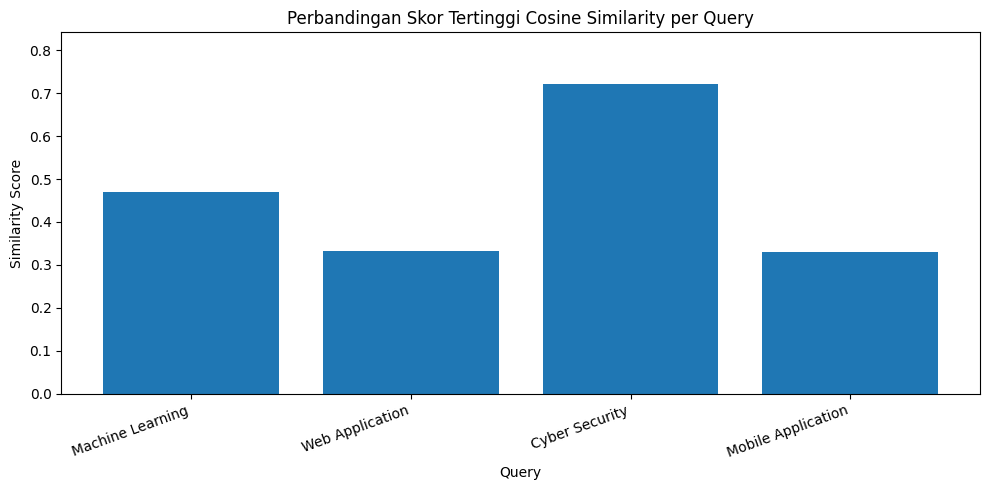

In [15]:
# =========================================================
# CELL 15 - GRAFIK BATANG SKOR TERTINGGI COSINE SIMILARITY
# Gambar 4.1: Perbandingan Skor Tertinggi Cosine Similarity per Query
# =========================================================
import matplotlib.pyplot as plt

query_files = [
    ("Machine Learning", "similarity_score_machine_learning.csv"),
    ("Web Application", "similarity_score_web_application.csv"),
    ("Cyber Security", "similarity_score_cyber_security.csv"),
    ("Mobile Application", "similarity_score_mobile_application.csv"),
]

chart_rows = []

for query_label, filename in query_files:
    csv_path = os.path.join(results_dir, filename)
    cosine_df = pd.read_csv(csv_path)
    top_row = cosine_df.sort_values("similarity_score", ascending=False).iloc[0]

    chart_rows.append({
        "query": query_label,
        "similarity_score": float(top_row["similarity_score"]),
        "article_id": int(top_row["id"]),
        "title": top_row["title"],
        "source_file": filename,
    })

chart_df = pd.DataFrame(chart_rows)
display(chart_df[["query", "article_id", "similarity_score", "source_file"]])

plt.figure(figsize=(10, 5))
plt.bar(chart_df["query"], chart_df["similarity_score"], color="#1f77b4")
plt.title("Perbandingan Skor Tertinggi Cosine Similarity per Query")
plt.xlabel("Query")
plt.ylabel("Similarity Score")
plt.ylim(0, max(chart_df["similarity_score"]) + 0.12)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()